# IMDB Movie Reviews Sentiment Analysis (Week 05)
**Author:** Recently graduated Software Engineering student (Data Science foundation)

This notebook follows the required steps: Import → Load → EDA → Preprocess → Split → Vectorize → Train → Evaluate → Save.

## Step 1: Import Libraries

In [1]:
import re, os, io, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


## Step 2: Load the Dataset

In [2]:
csv_path= "IMDB Dataset.csv"
df = pd.read_csv(csv_path, on_bad_lines="skip", quoting=0)
df.head() 

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Step 3: Exploratory Data Analysis (EDA)

Shape: (50000, 2)
Columns: ['review', 'sentiment']
Dtypes:
 review       object
sentiment    object
dtype: object
Duplicate rows: 418
Null counts:
 review       0
sentiment    0
dtype: int64


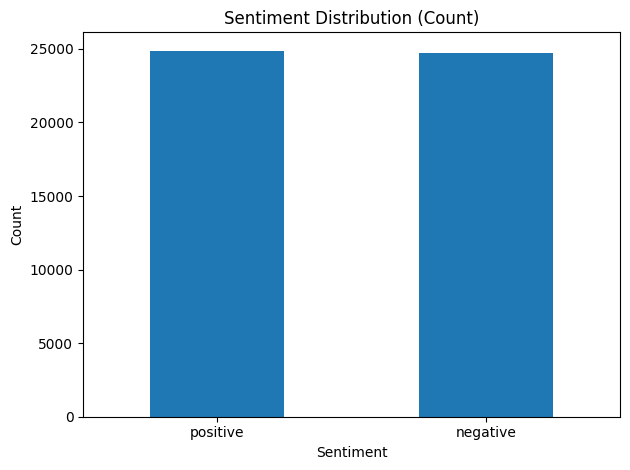

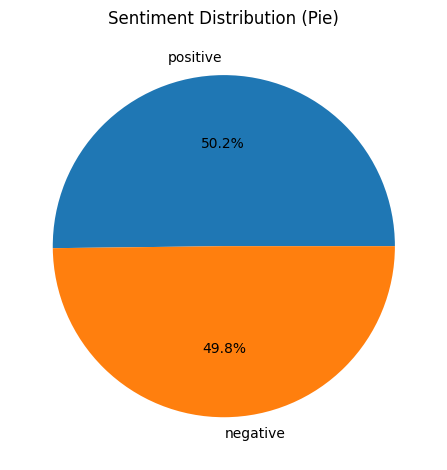

In [3]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Dtypes:\n", df.dtypes)
print("Duplicate rows:", df.duplicated().sum())
print("Null counts:\n", df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Sentiment distribution
sentiment_counts = df["sentiment"].value_counts()
plt.figure()
sentiment_counts.plot(kind="bar", rot=0, title="Sentiment Distribution (Count)")
plt.xlabel("Sentiment"); plt.ylabel("Count"); plt.tight_layout(); plt.show()

plt.figure()
sentiment_counts.plot(kind="pie", autopct="%1.1f%%", title="Sentiment Distribution (Pie)")
plt.ylabel(""); plt.tight_layout(); plt.show()

## Step 4: Data Preprocessing

In [4]:
# Encode target
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Clean text
import nltk
try:
    nltk.download("stopwords", quiet=True)
    from nltk.corpus import stopwords
    STOPWORDS = set(stopwords.words("english"))
except Exception:
    STOPWORDS = set(["a","an","the","and","or","but","if","in","on","with","to","of","is","are","was","were","be","been","being","for","at","by"])

def clean_text(text: str) -> str:
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)        # remove HTML
    text = re.sub(r"[^a-zA-Z]", " ", text)    # keep letters only
    text = text.lower()
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 1]
    return " ".join(tokens)

df["clean_review"] = df["review"].astype(str).apply(clean_text)
df[["review","clean_review","sentiment"]].head(3)

,review,clean_review,sentiment
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode ho...,1
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,1
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,1


## Step 5: Split Data into Train/Test

In [5]:
X = df["clean_review"]
y = df["sentiment"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
len(X_train), len(X_test)

(39665, 9917)

## Step 6: TF-IDF Vectorization (max_features=5000)

In [6]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
X_train_tfidf.shape, X_test_tfidf.shape

((39665, 5000), (9917, 5000))

## Step 7: Train Multinomial Naive Bayes

In [7]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


## Step 8: Evaluation — Accuracy, Precision, Recall, F1, Confusion Matrix

Accuracy: 0.8551

              precision    recall  f1-score   support

    negative       0.86      0.85      0.85      4940
    positive       0.85      0.86      0.86      4977

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



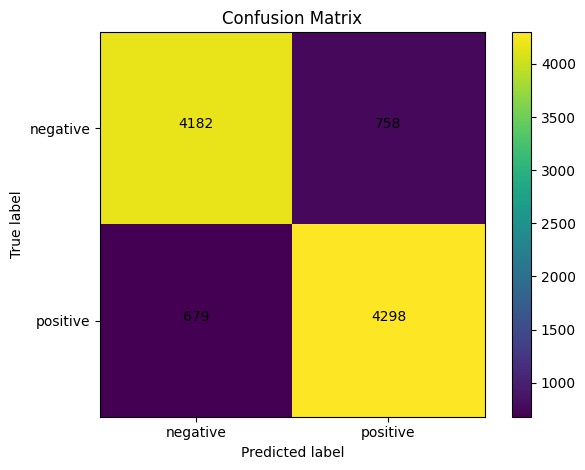

In [8]:
y_pred = model.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=["negative","positive"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["negative", "positive"])
plt.yticks(tick_marks, ["negative", "positive"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"), ha="center")
plt.ylabel("True label"); plt.xlabel("Predicted label"); plt.tight_layout(); plt.show()

## Step 9: Important Words (Most Indicative)

In [9]:
feature_names = np.array(tfidf.get_feature_names_out())
log_probs = model.feature_log_prob_   # [neg, pos]
pos_strength = log_probs[1] - log_probs[0]
neg_strength = log_probs[0] - log_probs[1]

top_k = 20
top_pos_idx = np.argsort(pos_strength)[-top_k:][::-1]
top_neg_idx = np.argsort(neg_strength)[-top_k:][::-1]

top_positive_words = list(zip(feature_names[top_pos_idx].tolist(), pos_strength[top_pos_idx].tolist()))
top_negative_words = list(zip(feature_names[top_neg_idx].tolist(), neg_strength[top_neg_idx].tolist()))

print("Top Positive Words:")
for w, s in top_positive_words:
    print(f"{w:>15s}  {s:.4f}")
print("\nTop Negative Words:")
for w, s in top_negative_words:
    print(f"{w:>15s}  {s:.4f}")

Top Positive Words:
          ponyo  2.4807
        matthau  2.3688
          felix  2.1620
       flawless  2.0664
         custer  1.9677
       timeless  1.9314
    wonderfully  1.9121
  unforgettable  1.8846
       superbly  1.8645
    understated  1.8350
         superb  1.7879
     underrated  1.7722
     refreshing  1.7673
     perfection  1.7641
     delightful  1.7524
       captures  1.7452
     cassavetes  1.7332
       touching  1.7320
       miyazaki  1.7133
    beautifully  1.7053

Top Negative Words:
          waste  2.8393
           boll  2.6926
            uwe  2.6406
        stinker  2.5897
          worst  2.5638
        unfunny  2.4619
            mst  2.4411
          awful  2.4232
      redeeming  2.3798
    unwatchable  2.2757
  uninteresting  2.2628
        wasting  2.2595
         seagal  2.2562
     incoherent  2.2478
         poorly  2.2031
      laughable  2.1813
     amateurish  2.1742
      atrocious  2.1493
      pointless  2.1462
     uninspired  2.0969

## Step 10: Save Model and Vectorizer

In [ ]:
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(model, f)
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)
"sentiment_model.pkl", "tfidf_vectorizer.pkl" 

('/mnt/data/sentiment_model.pkl', '/mnt/data/tfidf_vectorizer.pkl')